# Section 2: Ridge Regression

## Question 4: Ridge Regression



### Part 1: Mathematical Derivation



#### 1. Analytical Solution in Matrix Form





To find the analytical solution, we need to minimize the empirical risk $E(b, w)$. We achieve this by setting the partial derivative with respect to $b$ and the gradient with respect to $w$ to zero. 

The empirical risk is defined as:
$$ E(b,w) = \frac{1}{2n}||y - b\mathbf{1} - Xw||_2^2 + \frac{\lambda}{2}||w||_2^2 $$

**Step 1: Derivative and Solution for the intercept $b$**

First, we take the partial derivative of $E$ with respect to $b$. Applying the chain rule, and noting that the regularization term $\frac{\lambda}{2}||w||_2^2$ is treated as a constant with respect to $b$:

$$ \frac{\partial E}{\partial b} = \frac{1}{2n} \cdot 2(y - b\mathbf{1} - Xw)^T \cdot \frac{\partial}{\partial b}(y - b\mathbf{1} - Xw) $$

The derivative of the inner function with respect to $b$ is $-\mathbf{1}$. By applying the matrix transpose rule to properly align the dimensions for multiplication:

$$ \frac{\partial E}{\partial b} = \frac{1}{n} (y - b\mathbf{1} - Xw)^T (-\mathbf{1}) = -\frac{1}{n} \mathbf{1}^T (y - b\mathbf{1} - Xw) $$

Setting the derivative to zero:
$$ -\frac{1}{n} \mathbf{1}^T (y - b\mathbf{1} - Xw) = 0 $$
$$ \mathbf{1}^T y - b\mathbf{1}^T \mathbf{1} - \mathbf{1}^T Xw = 0 $$

Since $\mathbf{1}^T \mathbf{1} = n$, we can isolate $b$:
$$ bn = \mathbf{1}^T (y - Xw) $$
$$ b = \frac{1}{n} \mathbf{1}^T (y - Xw) $$

**Step 2: Derivative and Solution for the weights $w$**

Next, we take the gradient of $E$ with respect to $w$. We apply the chain rule to both terms:

$$ \nabla_w E = \frac{1}{2n} \cdot 2 \cdot (-X)^T (y - b\mathbf{1} - Xw) + \frac{\lambda}{2} \cdot 2w $$
$$ \nabla_w E = -\frac{1}{n} X^T (y - b\mathbf{1} - Xw) + \lambda w $$

Setting the gradient to zero:
$$ -\frac{1}{n} X^T (y - b\mathbf{1} - Xw) + \lambda w = 0 $$

To solve for $w$ without $b$ interfering, we can substitute the expression for $b$ we found above into the residual $(y - b\mathbf{1} - Xw)$. Mathematically, this is equivalent to centering the data. Let $M = I - \frac{1}{n}\mathbf{1}\mathbf{1}^T$ be the centering matrix. By applying $M$, we get the mean-centered target vector $\tilde{y} = My$ and the mean-centered feature matrix $\tilde{X} = MX$. 

Using the centered data, the unregularized intercept $b$ is eliminated from the gradient equation:
$$ -\frac{1}{n} \tilde{X}^T (\tilde{y} - \tilde{X}w) + \lambda w = 0 $$

Expanding and rearranging the terms to isolate $w$:
$$ \frac{1}{n} \tilde{X}^T \tilde{X} w + \lambda w = \frac{1}{n} \tilde{X}^T \tilde{y} $$
$$ (\frac{1}{n} \tilde{X}^T \tilde{X} + \lambda I) w = \frac{1}{n} \tilde{X}^T \tilde{y} $$
$$ (\tilde{X}^T \tilde{X} + n\lambda I) w = \tilde{X}^T \tilde{y} $$

By multiplying both sides by the inverse matrix, we obtain the final analytical solution:
$$ w = (\tilde{X}^T \tilde{X} + n\lambda I)^{-1} \tilde{X}^T \tilde{y} $$
$$ b = \frac{1}{n} \mathbf{1}^T (y - Xw) $$
*(Where $\tilde{X}$ and $\tilde{y}$ are the mean-centered data, and $I$ is the identity matrix)*

#### 2. Existence and Uniqueness of the Solution






In ordinary linear regression, finding the solution requires computing the inverse of the matrix $X^T X$ (or $\tilde{X}^T \tilde{X}$ for centered data). However, **before any regularization is applied**, $X^T X$ can naturally be a **singular matrix** (meaning it is mathematically "broken" and impossible to invert). This happens if the features are highly correlated or if the number of features exceeds the number of samples. When it cannot be inverted, an infinite number of solutions exist.

The introduction of the Ridge penalty $\lambda > 0$ acts as a mathematical fix to guarantee the matrix is invertible. Here is exactly how it works:

1. **The Starting Point (Positive Semi-Definite):** By mathematical definition, the original unregularized matrix $X^T X$ is always *positive semi-definite*. The word "semi" is crucial here: it means its eigenvalues are greater than **or equal to** zero ($\ge 0$). If the matrix is singular (un-invertible), it means at least one of its eigenvalues has hit exactly $0$.
2. **The Rescue Term:** The Ridge penalty adds a new term $n\lambda I$ to the singular $X^T X$. The identity matrix $I$ has eigenvalues of exactly $1$.
3. **Upgrading to Strictly Positive Definite:** When we add $n\lambda I$ (where $\lambda > 0$), we are effectively adding a positive number ($n\lambda$) to every single eigenvalue of the original $X^T X$. Any eigenvalue that was previously $0$ is now forced to become $n\lambda$. Because $n\lambda > 0$, the smallest eigenvalue of the new combined matrix $(X^T X + n\lambda I)$ is now strictly greater than $0$.
4. **Guaranteed Invertibility:** Because the new matrix $(X^T X + n\lambda I)$ no longer contains any $0$ eigenvalues, it is upgraded to being **strictly positive definite**. A strictly positive definite matrix is always full-rank and non-singular, meaning it is 100% guaranteed to have an inverse.

Since the new matrix $(X^T X + n\lambda I)$ is always invertible, the equation $w = (X^T X + n\lambda I)^{-1} X^T y$ will always safely compute one single, deterministic, and **unique solution** for the weights $w$.

#### 3. Geometric Interpretation of the Ridge Penalty




* **Geometric Constraint:** In standard Ordinary Least Squares (OLS) regression, the objective is to find the minimum of the elliptical contours representing the sum of squared errors. The introduction of the Ridge penalty $\frac{\lambda}{2} ||w||_2^2$ geometrically acts as an additional constraint boundary. It forces the weight vector $w$ to lie within a **hypersphere** centered at the origin. The final Ridge solution is the point where the OLS error contours first intersect with the boundary of this penalty hypersphere.
* **Coefficient Shrinkage:** The parameter $\lambda$ controls the size of this hypersphere. As $\lambda$ increases, the radius of the hypersphere shrinks. This tightening boundary forces the intersection point closer to the origin, thereby directly "shrinking" the magnitude of the coefficient vector $w$ towards zero.
* **Unregularized Intercept:** According to the defined empirical risk function $E(b,w)$, the penalty term strictly applies only to the feature weights $w$; the intercept $b$ is explicitly excluded. Geometrically, this means the spherical constraint only exists in the multidimensional space of the features. The intercept $b$ remains unconstrained and is free to shift the decision boundary vertically to align with the global mean of the target variable $y$.

#### 4. Expected Behaviour in Extreme Scenarios




* **Scenario 1: $\lambda \rightarrow 0$**
  As the penalty parameter approaches zero, the regularization term $\frac{\lambda}{2} ||w||_2^2$ effectively vanishes from the objective function. The optimization problem reverts entirely to the standard unregularized Ordinary Least Squares (OLS) regression. If the design matrix $X^T X$ is invertible, the model will output the exact, un-shrunk OLS solution; if the data suffers from multicollinearity, the model remains highly susceptible to overfitting.

* **Scenario 2: $\lambda \rightarrow \infty$**
  As the penalty parameter approaches infinity, the regularization term overwhelmingly dominates the objective function. To minimize this infinitely large penalty, the geometric hypersphere is compressed to a single point at the origin, forcing all feature weights $w \rightarrow 0$. Consequently, all feature inputs become irrelevant. The model collapses into a flat horizontal line, relying entirely on the unregularized intercept $b$ (which will simply equal the mean of the training targets $y$), resulting in severe model **underfitting**.

### Part 2: Implementation and Numerical Verification

In this section, Ridge Regression is implemented from scratch using stochastic gradient descent (SGD). The implementation adheres to the standard estimator structure, utilizing `fit`, and `predict` methods. A numerical experiment is subsequently conducted to verify the SGD parameters against the exact analytical Ridge solution.

#### 1. Ridge Objective Function and Stochastic Gradient Descent

The model is designed to minimize the following regularized empirical risk:

$$
E(b,\mathbf{w}) = \frac{1}{2n} \left\| \mathbf{y} - b\mathbf{1} - X\mathbf{w} \right\|_2^2 + \frac{\lambda}{2} \left\| \mathbf{w} \right\|_2^2
$$

The first term measures the mean squared prediction error, while the second term applies an L2 penalty to discourage excessively large coefficients. The intercept $b$ is handled separately and is explicitly excluded from the regularization penalty; thus, the model only penalizes the coefficient vector $\mathbf{w}$.

For an individual training observation $(\mathbf{x}_i,y_i)$, the prediction $\hat{y}_i$ and error $e_i$ are computed to derive the stochastic gradients:

$$
\nabla_{\mathbf{w}}E_i = e_i\mathbf{x}_i + \lambda\mathbf{w}, \qquad \nabla_b E_i = e_i
$$

The model parameters are then iteratively updated in the opposite direction of the gradients using a specified learning rate $\eta$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta\nabla_{\mathbf{w}}E_i, \qquad b \leftarrow b - \eta\nabla_b E_i
$$

**Optimization Settings:** 
To ensure robust convergence, the training indices are randomly permuted at the beginning of each epoch, ensuring every observation is processed in a varying order. For the numerical verification, this permutation is made reproducible by setting `random_state=5201`. Furthermore, early stopping is disabled (`tol=0`), compelling the model to complete the full specified number of epochs rather than halting prematurely. Since the Ridge objective is a convex quadratic function, it possesses a unique global minimum for any $\lambda > 0$, guaranteeing that the SGD algorithm will converge appropriately even if $X^TX$ is singular.

#### 2. Numerical Verification

To verify the SGD implementation, a synthetic dataset comprising 100 observations and three input features was generated according to the following process:

$$
y = 3x_1 - 2x_2 + 0x_3 + 1.5 + \epsilon, \qquad \epsilon \sim \mathcal{N}(0,0.1^2)
$$

The true generative parameters are therefore $\mathbf{w}_{\text{true}} = [3, -2, 0]$ and $b_{\text{true}} = 1.5$. 

To compute the analytical Ridge solution without regularizing the intercept, the feature matrix and target vector are first mean-centered ($X_c = X - \bar{X}$ and $\mathbf{y}_c = \mathbf{y} - \bar{y}$). The exact analytical coefficients and intercept are then determined via the closed-form solution:

$$
\mathbf{w}_{\text{analytical}} = \left(X_c^T X_c + n\lambda I \right)^{-1} X_c^T \mathbf{y}_c
$$
$$
b_{\text{analytical}} = \bar{y} - \bar{X}^T\mathbf{w}_{\text{analytical}}
$$


#### RidgeRegressorSGD Implementation



In [1]:
import numpy as np
from sklearn.base import BaseEstimator

In [2]:
class RidgeRegressorSGD(BaseEstimator):
    def __init__(self, reg_lambda=1.0, learning_rate=0.001, n_epochs=10000, tol=1e-8, random_state=None):
        self.reg_lambda = reg_lambda          # Ridge regularisation strength λ; larger values constrain the weights w more strongly
        self.learning_rate = learning_rate    # Learning rate: the step size used for each parameter update
        self.n_epochs = n_epochs              # Maximum number of full passes through the training set
        self.tol = tol                        # Tolerance: stop early if the change in loss between consecutive epochs is smaller than this value
        self.random_state = random_state      # Fix the random seed so the shuffled sample order is reproducible

    def fit(self, X, y):
        # ============================================================
        # Module 1: Initialise the random number generator and model parameters
        # ============================================================
        rng = np.random.default_rng(self.random_state)  # Prepare a random number generator for shuffling the training samples
        n_samples, n_features = X.shape                  # Extract the number of samples n and number of features d

        self.w = np.zeros(n_features)                    # Initialise the d feature weights to 0
        self.b = 0.0                                     # Initialise the intercept b to 0
        prev_loss = np.inf                               # There is no previous loss in the first epoch, so initialise it to positive infinity

        # ============================================================
        # Module 2: Train for multiple epochs
        # ============================================================
        for epoch in range(self.n_epochs):
            indices = rng.permutation(n_samples)         # Randomly permute sample indices 0 through n-1 so each epoch uses a different order
            # Stochastic gradient descent: process one sample at a time in the shuffled order
            for i in indices:
                xi = X[i]                                # Extract all features of sample i, with shape (n_features,)
                yi = y[i]                                # Extract the true target for sample i

                y_pred_i = np.dot(xi, self.w) + self.b    # Use the current w and b to compute the prediction xi·w+b
                error_i = y_pred_i - yi                   # Compute the prediction error; positive means overprediction and negative means underprediction

                grad_w = error_i * xi + self.reg_lambda * self.w  # Prediction-error gradient plus the Ridge penalty on large weights
                grad_b = error_i                          # The gradient for b is the current error because the intercept is not regularised

                self.w -= self.learning_rate * grad_w     # Move the weights a small step opposite the gradient to reduce the loss
                self.b -= self.learning_rate * grad_b     # Update the intercept b in the same way

            # ========================================================
            # Module 3: At the end of the current epoch, compute the total loss on all training data
            # ========================================================
            y_pred_full = np.dot(X, self.w) + self.b      # Use the updated w and b to predict all training samples

            mse_loss = np.mean((y - y_pred_full) ** 2) / 2  # Compute mean squared error; division by 2 simplifies the derivative
            reg_loss = (self.reg_lambda / 2) * np.sum(self.w ** 2)  # Compute the L2 penalty; larger weights incur a larger penalty

            current_loss = mse_loss + reg_loss            # Total Ridge loss = prediction error + regularisation penalty

            # ========================================================
            # Module 4: Check whether the model has converged
            # ========================================================
            if abs(prev_loss - current_loss) < self.tol:  # If the loss changes very little between consecutive epochs
                break                                     # Further training is unlikely to help, so stop early
            prev_loss = current_loss                      # Save this epoch's loss for comparison in the next epoch

        return self                                       # Return the fitted model containing w and b


    def predict(self, X):  # Use the fitted parameters to predict new data
        return np.dot(X, self.w) + self.b                 # Compute Xw+b for each sample to obtain the final predictions

#### Numerical Verification



In [3]:
# ============================================================
# Module 1: Generate a test dataset with known target values
# ============================================================
np.random.seed(5201)                                      # Fix the data-generation seed so every run produces the same test data
X_test_dummy = np.random.randn(100, 3)                    # Generate 100 samples with 3 features each, giving X shape (100, 3)

y_test_dummy = (                                          # Generate 100 target values from the predefined linear relationship
    3 * X_test_dummy[:, 0]                                # The true weight of the first feature is 3
    - 2 * X_test_dummy[:, 1]                              # The true weight of the second feature is -2
    + 1.5                                                 # The true intercept is 1.5
    + np.random.randn(100) * 0.1                          # Add random noise with mean 0 and standard deviation 0.1 to make the data more realistic
)

reg_lambda_test = 0.5                                     # Set Ridge regularisation strength λ=0.5 for the test. It is positive, so it tests regularisation; large enough to show weight shrinkage, but not so large that weights collapse to almost zero
n = X_test_dummy.shape[0]                                 # Extract the sample count n=100 for use in the analytical formula below


# ============================================================
# Module 2: Run the SGD Ridge regression model
# ============================================================
sgd_model = RidgeRegressorSGD(
    reg_lambda=reg_lambda_test,                           # Use the same λ as the analytical solution for a fair comparison
    learning_rate=0.001,                                  # Use a small parameter-update step to avoid oscillation near the optimum
    n_epochs=500,                                         # Make at most 500 full passes through the training set
    random_state=5201                                     # Fix the SGD shuffle order for reproducibility
)

sgd_model.fit(X_test_dummy, y_test_dummy)                  # Fit the model on the test data to obtain the SGD estimates self.w and self.b

# ============================================================
# Module 3: Compute the optimal parameters directly using the analytical solution from Part 1
# ============================================================
# Because intercept b is not regularised, centre X and y first to separate the intercept from the calculation
X_mean = np.mean(X_test_dummy, axis=0)                     # Compute the mean of each of the three features, giving shape (3,)
y_mean = np.mean(y_test_dummy)                             # Compute the mean of all 100 target values, giving a scalar

X_centered = X_test_dummy - X_mean                         # Subtract each feature's mean so all three centred features have mean 0
y_centered = y_test_dummy - y_mean                         # Subtract the target mean so the centred targets have mean 0

# Apply the formula w = (XᵀX + nλI)⁻¹Xᵀy
I = np.eye(X_centered.shape[1])                            # Create a 3×3 identity matrix I so λ penalises only the three corresponding feature weights

w_analytical = (                                          
    np.linalg.inv(                                        # Compute the inverse of (XᵀX+nλI)
        X_centered.T @ X_centered                          # Compute XᵀX, producing shape (3, 3)
        + n * reg_lambda_test * I                          # Add nλI to apply Ridge regularisation
    )
    @ X_centered.T                                        # Multiply the inverse matrix by Xᵀ
    @ y_centered                                          # Then multiply by centred y to obtain the analytical weights w
)
b_analytical = y_mean - np.dot(X_mean, w_analytical)      # Recover the unregularised intercept using b=ȳ-x̄ᵀw

print("=== Numerical Verification ===")                    
print(f"SGD w:        {sgd_model.w}")                      
print(f"Analytical w: {w_analytical}")                    
print("-" * 30)                                          
print(f"SGD b:        {sgd_model.b:.5f}")                  
print(f"Analytical b: {b_analytical:.5f}")                 

=== Numerical Verification ===
SGD w:        [ 2.21437278 -1.40777221  0.09853157]
Analytical w: [ 2.21105522 -1.40590233  0.09952979]
------------------------------
SGD b:        1.48268
Analytical b: 1.48143



**Verification Results:**

Using a regularization strength of $\lambda=0.5$, the outputs of the SGD implementation were compared against the analytical solution:

| Parameter | SGD Result | Analytical Result | Absolute Difference |
| :--- | :--- | :--- | :--- |
| $w_1$ | 2.214373 | 2.211055 | 0.003318 |
| $w_2$ | -1.407772 | -1.405902 | 0.001870 |
| $w_3$ | 0.098532 | 0.099530 | 0.000998 |
| $b$ | 1.482680 | 1.481430 | 0.001250 |

**Conclusion:**

The parameters derived from the SGD approach are virtually identical to the analytical results, confirming that the custom implementation correctly minimizes the Ridge objective function. 

Notably, the Ridge solution is not expected to perfectly reproduce the original generative coefficients $[3, -2, 0]$. At $\lambda=0.5$, the regularization term deliberately shrinks the magnitude of the coefficients toward zero. Furthermore, due to the presence of Gaussian noise and the limited sample size ($n=100$), the estimated coefficients will naturally deviate slightly from the true parameters. Therefore, the numerical verification correctly relies on demonstrating that $\mathbf{w}_{\text{SGD}} \approx \mathbf{w}_{\text{analytical}}$, rather than expecting $\mathbf{w}_{\text{SGD}} = \mathbf{w}_{\text{true}}$.

### Part 3: Regularisation and Model Complexity




In this section, an empirical experiment is conducted to investigate how the regularization strength ($\lambda$) affects model complexity, the coefficient norm, and the fundamental bias-variance trade-off.

### 1. Experimental Setup and Data Generation

The true data-generating process (DGP) is defined by a non-linear function with Gaussian noise:
$$ y = \sin^2(2\pi x) + 3x + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, 0.1^2) $$
> $y$: true target value; $x$: raw input feature uniformly sampled from $[-0.6, 0.6]$; $\epsilon$: irreducible Gaussian noise; $\mathcal{N}(0, 0.1^2)$: Normal distribution with a mean of 0 and a standard deviation of 0.1.  

where $x$ is uniformly sampled from the interval $[-0.6, 0.6]$. 

To capture the non-linearity, a degree-six polynomial regression model is constructed:
$$ \hat{y}_i = b + \sum_{j=1}^6 w_j x_i^j $$
> $\hat{y}$: predicted target value estimated by the model; $b$: unregularized intercept; $w_1, \dots, w_6$: polynomial feature weights (coefficients) subject to Ridge regularization.  

The features are scaled (standardized) prior to training to ensure numerical stability during the Stochastic Gradient Descent (SGD) optimization. The intercept $b$ is calculated separately and is explicitly excluded from the regularization penalty.

**Evaluation Framework:**
To evaluate the stability and variance of the model, 30 independent training datasets (each containing $N=20$ samples) are generated. A single large test dataset ($N=5000$) is generated to act as the true population distribution. The model is evaluated across 25 geometrically spaced values of $\lambda \in [10^{-8}, 10^2]$.

### 2. Evaluated Mathematical Metrics

For each value of $\lambda$ across the 30 training repetitions ($R=30$), the following metrics are computed:

*   **Mean Squared Error (MSE):** Used to compute both training and test errors.
    $$ \text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2 $$
    > $N$: total number of samples in the dataset; $y_i$: true target value for the $i$-th sample; $\hat{y}_i$: predicted value for the $i$-th sample.   
    
*   **Coefficient Norm:** The L2 norm of the fitted feature weights (excluding the intercept) measures the shrinkage effect.
    $$ ||\hat{\mathbf{w}}||_2 = \sqrt{\sum_{j=1}^6 w_j^2} $$
    > $||\hat{\mathbf{w}}||_2$: L2 norm (Euclidean length) of the estimated weight vector; $\hat{w}_j$: the $j$-th estimated polynomial coefficient.

*   **Test MSE Variability (Standard Deviation):** Measures the stability of the model's predictions across different training sets.
    $$ \text{SD}_{\text{Test MSE}} = \sqrt{\frac{1}{R-1} \sum_{r=1}^R \left(\text{MSE}_r^{\text{test}} - \overline{\text{MSE}}^{\text{test}}\right)^2} $$
    > $\text{SD}_{\text{Test MSE}}$: sample standard deviation of the test MSEs; $R$: number of independent training repetitions ($R=30$); $\text{MSE}_r^{\text{test}}$: test MSE obtained from the model trained in the $r$-th repetition; $\overline{\text{MSE}}^{\text{test}}$: overall mean test MSE across all $R$ repetitions.



#### Experimental Setup 




In [4]:
# Module 1: Generate simulated data using the formula specified in the question
def generate_data(n_samples, seed):
    rng = np.random.default_rng(seed)                        # Create a random number generator from the specified seed; identical seeds produce identical data
    x = rng.uniform(-0.6, 0.6, n_samples)                    # Generate n_samples values of x from Uniform(-0.6, 0.6)
    epsilon = rng.normal(0, 0.1, n_samples)                  # Generate noise with mean 0 and standard deviation 0.1, hence variance 0.1²
    y = np.sin(2 * np.pi * x) ** 2 + 3 * x + epsilon         # Generate the target for each x using y=sin²(2πx)+3x+ε
    return x, y                                              # Return one-dimensional x and y arrays, each with shape (n_samples,)

# Module 2: Transform the original x into sixth-degree polynomial features
def get_poly_features(x, degree=6):
    powers = [x ** i for i in range(1, degree + 1)]          # Generate x, x², x³, ..., x⁶; degree+1 is used because range excludes its endpoint
    return np.column_stack(powers)                            # Stack the powers as separate columns, giving final shape (n_samples, 6)

#### Experimental Results


In [5]:
# ============================================================
# Module 1: Set the basic parameters and initialise storage
# ============================================================
n_train_reps = 30                                         # Repeat the training experiment 30 times
n_train_samples = 20                                      # Generate 20 samples for each training run to simulate a small training set
n_test_samples = 5000                                     # Generate 5,000 samples as a large fixed test set representing the population distribution
lambdas = np.geomspace(1e-8, 1e2, 25)                     # Generate 25 geometrically spaced lambda values from 10^-8 to 10^2

# Generate a fixed test set using seed 5202
x_test, y_test = generate_data(n_test_samples, seed=5202) # Use fixed seed 5202 for a common test set, ensuring every lambda is evaluated against the same benchmark
X_test_poly = get_poly_features(x_test)                   # Transform the one-dimensional test feature into sixth-degree polynomial features, giving shape (5000, 6)

# Initialise arrays for storing the results
train_mse_results = np.zeros((len(lambdas), n_train_reps))# Initialise a matrix for training MSE across 25 lambda values and 30 repetitions each
test_mse_results = np.zeros((len(lambdas), n_train_reps)) # Initialise a matrix for test-set MSE
coef_norm_results = np.zeros((len(lambdas), n_train_reps))# Initialise a matrix for the L2 norm of model weights to measure coefficient shrinkage

# Use seed 5201 to generate the list of training-set seeds
rng_train = np.random.default_rng(5201)                   # Fix random seed 5201 for generating independent training-set seeds
dataset_seeds = rng_train.integers(0, 100000, size=n_train_reps) # Generate 30 seeds in advance so the datasets used in all repetitions are reproducible

# ============================================================
# Module 2: Train and evaluate in nested loops
# ============================================================
# The outer loop covers 25 lambda values, while the inner loop performs 30 repetitions
for i, lam in enumerate(lambdas):                         # Iterate over each specified lambda value
    for rep in range(n_train_reps):                       # Run 30 independent training experiments for the current lambda
        # Generate an independent training dataset in each repetition
        x_train, y_train = generate_data(n_train_samples, seed=dataset_seeds[rep]) # Use the corresponding pre-generated seed to create 20 training samples
        X_train_poly = get_poly_features(x_train)         # Transform the training set into sixth-degree polynomial features, giving shape (20, 6)
        
        # Standardise features so SGD converges reliably even for very small lambda values
        train_mean = np.mean(X_train_poly, axis=0)        # Compute the mean of each polynomial feature in the training set
        train_std = np.std(X_train_poly, axis=0)          # Compute the standard deviation of each polynomial feature in the training set
        X_train_scaled = (X_train_poly - train_mean) / train_std   # Standardise the training-set features
        X_test_rep_scaled = (X_test_poly - train_mean) / train_std # Standardise the test set using training means and standard deviations to prevent data leakage
        
        # Optimisation settings: after standardisation, learning_rate=0.01 and n_epochs=2000 ensure reliable convergence
        model = RidgeRegressorSGD(reg_lambda=lam, learning_rate=0.01, n_epochs=2000, tol=1e-5, random_state=5201) # Initialise the SGD Ridge regression model
        model.fit(X_train_scaled, y_train)                # Fit the model using the standardised training data
        
        # Compute and record the results
        y_train_pred = model.predict(X_train_scaled)      # Use the fitted model to predict the training set
        y_test_pred = model.predict(X_test_rep_scaled)    # Use the fitted model to predict the test set
        
        train_mse_results[i, rep] = np.mean((y_train_pred - y_train)**2) # Compute training-set mean squared error (MSE) and store it in the results matrix
        test_mse_results[i, rep] = np.mean((y_test_pred - y_test)**2)    # Compute test-set mean squared error (MSE) and store it in the results matrix
        coef_norm_results[i, rep] = np.linalg.norm(model.w)              # Compute and store the L2 norm of the weights (||w||_2) fitted on the 20 training samples in this repetition


# ============================================================
# Module 3: Compute the final mean metrics
# ============================================================
mean_train_mse = np.mean(train_mse_results, axis=1)       # For each lambda, compute mean training MSE across the 30 repetitions
mean_test_mse = np.mean(test_mse_results, axis=1)         # For each lambda, compute mean test MSE across the 30 repetitions
std_test_mse = np.std(test_mse_results, axis=1)           # For each lambda, compute the standard deviation of test MSE across the 30 repetitions to assess stability
mean_coef_norm = np.mean(coef_norm_results, axis=1)       # For each lambda, compute the mean coefficient L2 norm across the 30 repetitions

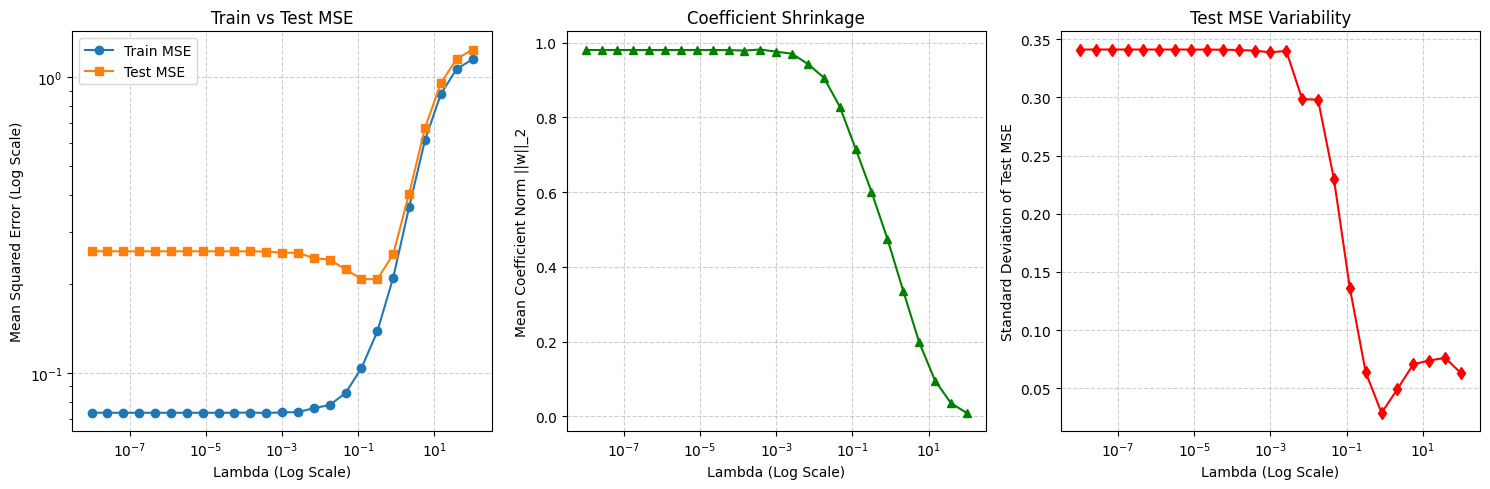

In [6]:
import matplotlib.pyplot as plt

# Set the figure size for three plots in one row
plt.figure(figsize=(15, 5))

# 1. First plot: Training and test MSE versus lambda, showing the bias-variance trade-off
# The visual indication of increasing bias is the rise in training MSE (blue line)
plt.subplot(1, 3, 1)
plt.plot(lambdas, mean_train_mse, label='Train MSE', marker='o')
plt.plot(lambdas, mean_test_mse, label='Test MSE', marker='s')
plt.xscale('log') # Lambda spans a wide range, so use a logarithmic x-axis
plt.yscale('log') # MSE also spans a wide range, so a logarithmic y-axis makes the pattern clearer
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('Train vs Test MSE')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 2. Second plot: Coefficient L2 norm versus lambda, showing coefficient shrinkage
plt.subplot(1, 3, 2)
plt.plot(lambdas, mean_coef_norm, color='green', marker='^')
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Mean Coefficient Norm ||w||_2')
plt.title('Coefficient Shrinkage')
plt.grid(True, linestyle='--', alpha=0.6)

# 3. Third plot: Standard deviation of test MSE versus lambda, showing test-MSE variability
plt.subplot(1, 3, 3)
plt.plot(lambdas, std_test_mse, color='red', marker='d')
plt.xscale('log')
plt.xlabel('Lambda (Log Scale)')
plt.ylabel('Standard Deviation of Test MSE')
plt.title('Test MSE Variability')
plt.grid(True, linestyle='--', alpha=0.6)

# Automatically adjust subplot spacing and display the figure
plt.tight_layout()
plt.show()

### 3. Discussion and Findings

All experiments used standardised polynomial features with `learning_rate=0.01`, `n_epochs=2000`, `tol=1e-5`, and `random_state=5201`.

Based on the three plots, the following patterns are observed:

* **Overfitting:** In the Train versus Test MSE plot, for $\lambda \in [10^{-8},10^{-3}]$, mean Train MSE remains approximately 0.073, while mean Test MSE is approximately 0.258. This large gap indicates that the flexible polynomial model fits the small training datasets more closely than it generalises to unseen data.

* **Optimal Generalisation:** Mean Test MSE reaches its minimum of approximately 0.207 at $\lambda \approx 0.316$. This value provides the best observed balance between fitting the signal and reducing sensitivity to noise.

* **Underfitting:** For large values, particularly $\lambda \in [10^1,10^2]$, excessive regularisation shrinks the coefficients towards zero and increases both training and test MSE. At $\lambda=100$, mean Train MSE and Test MSE reach approximately 1.151 and 1.242, respectively.

* **Coefficient Shrinkage:** The mean coefficient norm $\lVert\hat{\mathbf{w}}\rVert_2$ decreases from approximately 0.980 at $\lambda=10^{-8}$ to 0.009 at $\lambda=100$, confirming that stronger Ridge regularisation reduces model complexity.

* **Bias–Variance Trade-off:** Increasing $\lambda$ raises training error and therefore model bias, but initially reduces variability across training repetitions. Excessively large values then cause substantial underfitting.

* **Test MSE Variability:** Test MSE standard deviation decreases from approximately 0.341 at very small $\lambda$ to 0.064 at $\lambda\approx0.316$, and falls below 0.05 by $\lambda\approx2.15$. It rises slightly again for some very large values, but remains far below its level in the overfitting region.